<a href="https://colab.research.google.com/github/RichardMorris/TRUR2290-25-26/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering

Clustering is the main example of unsupervised learning. While there are many different algorithms for this process, we will be covering two of the most basic and most verstile.

This document covers *K Means* and *Hierarchal* clustering

# K Means

In [ ]:
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from scipy.cluster.hierarchy import dendrogram, linkage

### Generate Datasets

In [ ]:
# 1. Blobs - Ideal for K-Means
blobs_Positions, blobs_Colours = make_blobs(n_samples=500, centers=4, cluster_std=0.75)
blobs_Positions = [[float(point[0]), float(point[1])] for point in blobs_Positions]
blobs_X = [point[0] for point in blobs_Positions]
blobs_Y = [point[1] for point in blobs_Positions]

# 2. Moons - Ideal for Hierarchical Clustering
moons_Positions, moons_Colours = make_moons(n_samples=500, noise=0.05)
moons_Positions = [[float(point[0]), float(point[1])] for point in moons_Positions]
moons_X = [point[0] for point in moons_Positions]
moons_Y = [point[1] for point in moons_Positions]

# 3. Circles - Good for demonstrating clustering challenges
circles_Positions, circles_Colours = make_circles(n_samples=500, noise=0.05, factor=0.5)
circles_Positions = [[float(point[0]), float(point[1])] for point in circles_Positions]
circles_X = [point[0] for point in circles_Positions]
circles_Y = [point[1] for point in circles_Positions]


datasets = {
    "blobs": {
        "clusters": blobs_Colours,
        "positions": blobs_Positions,
        "x": blobs_X,
        "y": blobs_Y
    },
    "moons": {
        "clusters": moons_Colours,
        "positions": moons_Positions,
        "x": moons_X,
        "y": moons_Y
    },
    "circles": {
        "clusters": circles_Colours,
        "positions": circles_Positions,
        "x": circles_X,
        "y": circles_Y
    }
}

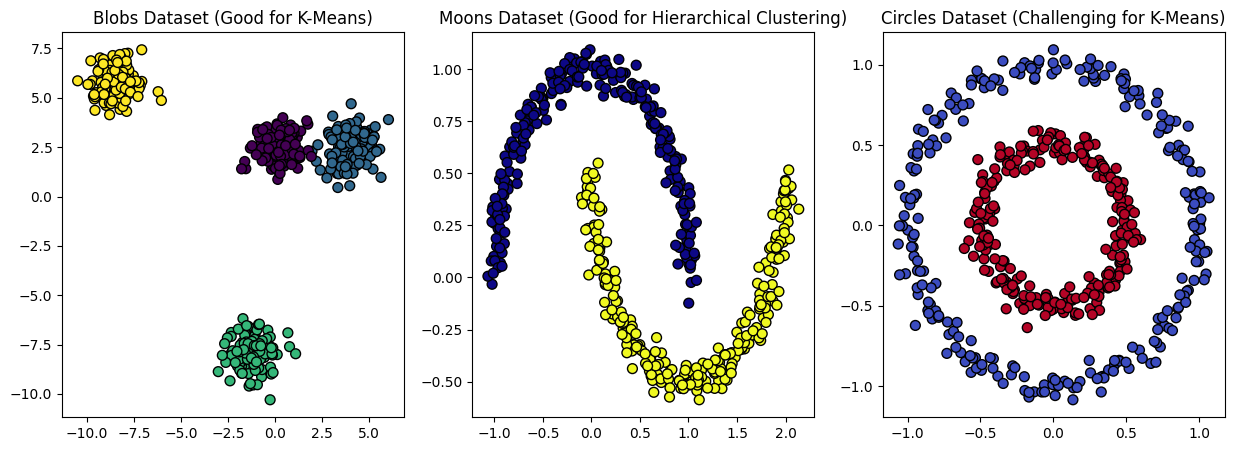

In [ ]:
# Plot the datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(blobs_X, blobs_Y, c=blobs_Colours, cmap='viridis', edgecolors='k', s=50)
axes[0].set_title("Blobs Dataset (Good for K-Means)")

axes[1].scatter(moons_X, moons_Y, c=moons_Colours, cmap='plasma', edgecolors='k', s=50)
axes[1].set_title("Moons Dataset (Good for Hierarchical Clustering)")

axes[2].scatter(circles_X, circles_Y, c=circles_Colours, cmap='coolwarm', edgecolors='k', s=50)
axes[2].set_title("Circles Dataset (Challenging for K-Means)")

plt.show()

## K-Means


1. Initialize K Centroids (randomly select K points).
2. Assign each data point to the nearest centroid.
3. Recalculate centroids by finding the center of points in each cluster.
4. Repeat until centroids no longer move significantly.


We'll be using the Blobs dataset for this example

In [ ]:
K = 4 # @param {type: "integer"}

datasetName = "blobs" # @param ["blobs", "moons", "circles"]
dataset = datasets[datasetName]["positions"]
xPos = datasets[datasetName]["x"]
yPos = datasets[datasetName]["y"]

### Initialise K Centroids

To initialise the centroids, we will randomly select K points from the data set. By selecting our centroids from the given dataset we don't need to define any form of boundary.

Text(0.5, 1.0, 'Initial Centroids')

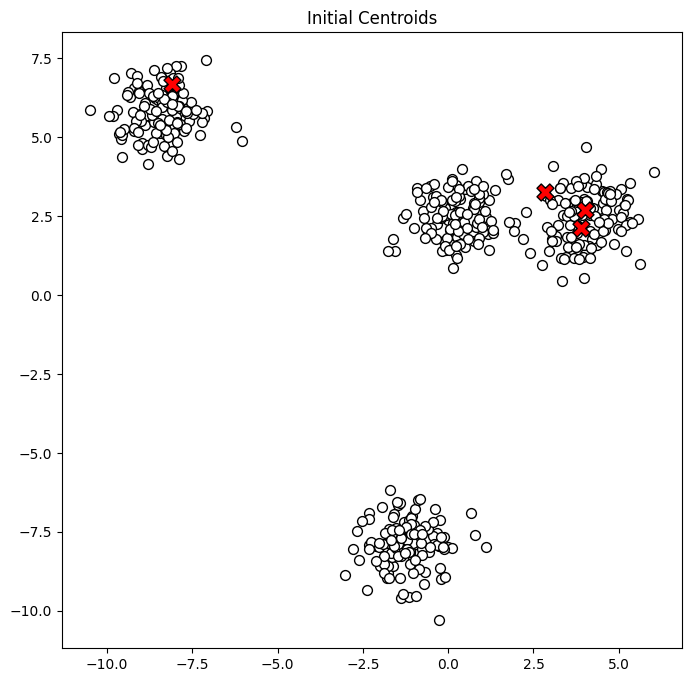

In [ ]:
centroids = random.sample(dataset, K)


fig, axes = plt.subplots(1, 1, figsize=(8, 8))

axes.scatter(xPos, yPos, c='w', edgecolors='k', s=50)
axes.scatter([point[0] for point in centroids], [point[1] for point in centroids], c='r',marker="X", s=150, edgecolors="k")
axes.set_title("Initial Centroids")

### Assign Each Point to Closest Centroid

<ipython-input-7-e7b0bc308882>:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes.scatter( [point[0] for point in centroids], [point[1] for point in centroids],


Text(0.5, 1.0, 'Assign All Points to Closest Centroid')

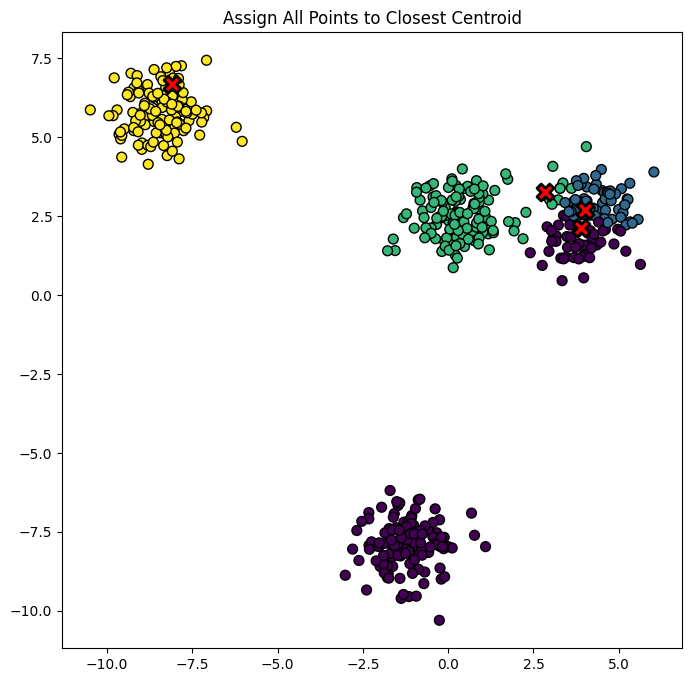

In [ ]:
## Define a function for calculating the distance
def distance(point, centroid):
  total = 0
  for i in range(len(point)):
    total += (point[i] - centroid[i]) ** 2
  return total ** 0.5


## For each point in the dataset, find the centroid with the lowest distance
K_Clusters = []
for point in dataset:
  closestIndex = -1
  closestDistance = float('inf')
  for index, centroid in enumerate(centroids):
    dist = distance(point, centroid)
    if dist < closestDistance:
      closestIndex = index
      closestDistance = dist
  K_Clusters.append(closestIndex)


## Graph the results
fig, axes = plt.subplots(1, 1, figsize=(8, 8))
axes.scatter(xPos, yPos,c=K_Clusters, cmap='viridis', edgecolors='k', s=50)
axes.scatter( [point[0] for point in centroids], [point[1] for point in centroids],
              c="r", cmap='viridis',marker="X", s=150, edgecolors='k', linewidths=2)
axes.set_title("Assign All Points to Closest Centroid")

### Update Centroids

Recalculate centroids by finding the center of points in each cluster.



<ipython-input-8-f1b7e873fea0>:20: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes.scatter([point[0] for point in new_Centroids], [point[1] for point in new_Centroids],c="r", cmap='viridis',marker="X", s=150, edgecolors='k', linewidths=2)


Text(0.5, 1.0, 'Update Centroid Positions')

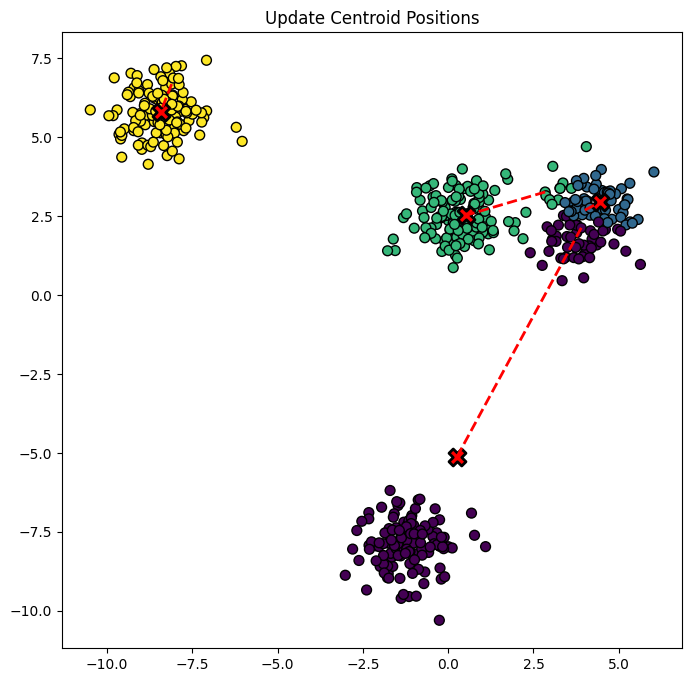

In [ ]:
## Create a list of each position with the cluster it's assigned to currently
zippedPositions = list(zip(dataset, K_Clusters))


## For each centroid, find the points assigned to it and average position
new_Centroids = [()] * K
for index, centroid in enumerate(centroids):
  relevantPositions = [point[0] for point in zippedPositions if point[1] == index]
  sumX = sum(point[0] for point in relevantPositions)
  sumY = sum(point[1] for point in relevantPositions)
  new_Centroids[index] = (sumX / len(relevantPositions), sumY / len(relevantPositions))


## Graph results
fig, axes = plt.subplots(1, 1, figsize=(8, 8))
axes.scatter(xPos, yPos,c=K_Clusters, cmap='viridis', edgecolors='k', s=50)
## Graphing lines that show the difference between original and new
for i in range(K):
  axes.plot([centroids[i][0], new_Centroids[i][0]], [centroids[i][1], new_Centroids[i][1]], marker='', linestyle='--', color='r', lw=2)
axes.scatter([point[0] for point in new_Centroids], [point[1] for point in new_Centroids],c="r", cmap='viridis',marker="X", s=150, edgecolors='k', linewidths=2)
axes.set_title("Update Centroid Positions")

## REPEAT

This code is the same as above, slightly editted to work off of `new_Centroids` rather than the `centroids` list we originally had

In [ ]:
K_Clusters = []
for point in dataset:
  closestIndex = -1
  closestDistance = float('inf')
  for index, centroid in enumerate(new_Centroids):
    dist = distance(point, centroid)
    if dist < closestDistance:
      closestIndex = index
      closestDistance = dist
  K_Clusters.append(closestIndex)



fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(xPos, yPos,c=K_Clusters, cmap='viridis', edgecolors='k', s=50)
axes[0].scatter([point[0] for point in new_Centroids], [point[1] for point in new_Centroids],c="r", marker="X", s=150, edgecolors='k', linewidths=2)
axes[0].set_title("Assign All Points to Closest Centroid")

zippedPositions = list(zip(dataset, K_Clusters))

new_Centroids = [()] * K
for index, centroid in enumerate(new_Centroids):
  relevantPositions = [point[0] for point in zippedPositions if point[1] == index]
  sumX = sum(point[0] for point in relevantPositions)
  sumY = sum(point[1] for point in relevantPositions)
  new_Centroids[index] = (sumX / len(relevantPositions), sumY / len(relevantPositions))

axes[1].scatter(xPos, yPos,c=K_Clusters, cmap='viridis', edgecolors='k', s=50)
axes[1].scatter([point[0] for point in new_Centroids], [point[1] for point in new_Centroids],c="r",marker="X", s=150, edgecolors='k', linewidths=2)
axes[1].set_title("Update Centroid Positions")

IndexError: tuple index out of range

# Hierarchical Clustering


While K-Means works really well and fast for spherical data, we need to define a value of K before hand, and will struggle to use it for a lot of real data.

An alternate here is Hierarchical clustering that is more effective but at the cost of more computations/time to run.

In [ ]:
datasetName = "moons" # @param ["blobs", "moons", "circles"]
dataset = datasets[datasetName]["positions"]
xPos = datasets[datasetName]["x"]
yPos = datasets[datasetName]["y"]

In [ ]:
## Find the average distance between points in two clusters
def clusterAverageDistance(clusterA, clusterB):
  total = 0
  ## Iterate through each pair of points and find thier distances
  for pointA in clusterA:
    for pointB in clusterB:
      total += distance(pointA, pointB)
  return total / (len(clusterA) * len(clusterB))



## Find the average distance between points in two clusters
def clusterMinimumDistance(clusterA, clusterB):
  minimum = float("inf")
  ## Iterate through each pair of points and find thier distances
  for pointA in clusterA:
    for pointB in clusterB:
      dist = distance(pointA, pointB)
      if minimum > dist:
        minimum = dist
  return minimum

In [ ]:
## Find the closest pair of clusters in a list of clusters
def closestClusters(clusters):
  minDist = float("inf")
  clusterPair = (-1, -1)

  for i in range(len(clusters)):
    for j in range(i+1, len(clusters)):
      dist = clusterMinimumDistance(clusters[i], clusters[j])
      if dist < minDist:
        minDist = dist
        clusterPair = (i, j)

  return clusterPair, dist

In [ ]:
## Initialise all data points as there own cluster
clusters = [[point] for point in dataset]

In [ ]:
## Find the two closest points and join them
closestPair, dist = closestClusters(clusters)

clusters[closestPair[0]].extend(clusters[closestPair[1]])
del clusters[closestPair[1]]

In [ ]:
## Repeat until distance is greater than some threshold
while len(clusters) > 2:
  closestPair, dist = closestClusters(clusters)

  clusters[closestPair[0]].extend(clusters[closestPair[1]])
  del clusters[closestPair[1]]

Text(0.5, 1.0, 'Hierarchal Clustering')

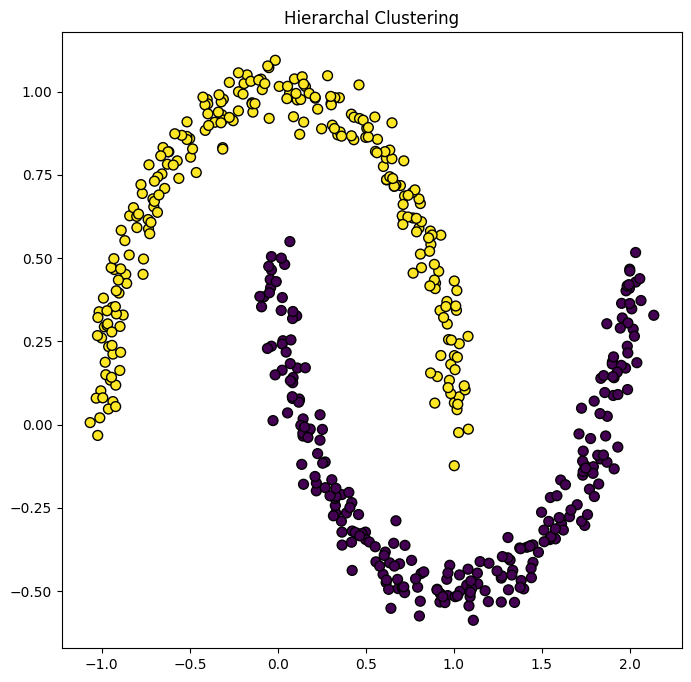

In [ ]:
def mapRelevantIndexes(points, clusters):
  colours = []
  for point in points:
    for i in range(len(clusters)):
      if point in clusters[i]:
        colours.append(i)
        continue
  return colours


fig, axes = plt.subplots(1, 1, figsize=(8, 8))
axes.scatter(xPos, yPos,c=mapRelevantIndexes(dataset, clusters), cmap='viridis', edgecolors='k', s=50)
axes.set_title("Hierarchal Clustering")

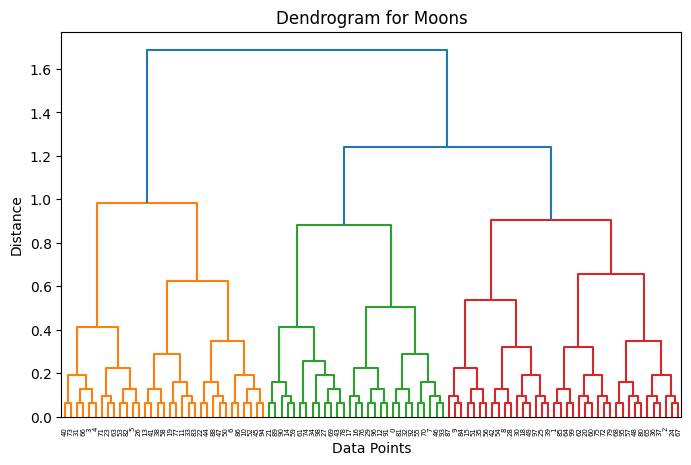

In [ ]:
X, _ = make_moons(n_samples=100, random_state=42)

# Perform Hierarchical Clustering
linkage_matrix = linkage(X, method='average')

# Plot the dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linkage_matrix)
plt.title("Dendrogram for Moons")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()